In [21]:
import pandas as pd
import numpy as np 

n_clientes=10
data={
    'id_clientes':range(1001,1001+n_clientes),
    'Edad':np.random.randint(18,80,size=n_clientes),
    'Salario_Estimado':np.random.choice([np.nan,2500,4000,5500,8000],size=n_clientes),#con nulos
    'Saldo_Bancario':np.random.uniform(0,50000,size=n_clientes),
    'Estado_Civil':np.random.choice(['Soltero','Casado','Divorciado',np.nan],size=n_clientes), #con nulos 
    'Genero':np.random.choice(['Masculino','Femenino'],size=n_clientes),
    'Nivel_Educativo':np.random.choice(['Secundario','Universitario','Posgrado'], size=n_clientes),
    'Acepta_Tarjeta':np.random.choice([0,1], size=n_clientes) #target
}
df_clientes=pd.DataFrame(data)
df_clientes['Estado_Civil']=df_clientes['Estado_Civil'].replace('nan',np.nan)
df_clientes

,id_clientes,Edad,Salario_Estimado,Saldo_Bancario,Estado_Civil,Genero,Nivel_Educativo,Acepta_Tarjeta
0,1001,77,4000.0,31762.287310,Soltero,Femenino,Universitario,0
1,1002,50,5500.0,46339.422225,Soltero,Femenino,Posgrado,0
2,1003,54,2500.0,5891.106390,Divorciado,Femenino,Posgrado,0
3,1004,56,4000.0,5553.325754,NaN,Masculino,Secundario,1
4,1005,44,NaN,36065.115210,NaN,Femenino,Secundario,1
5,1006,74,2500.0,33138.400469,Soltero,Masculino,Secundario,1
6,1007,25,8000.0,48770.895185,Casado,Femenino,Universitario,1
7,1008,61,8000.0,49867.593341,Soltero,Femenino,Universitario,1
8,1009,68,8000.0,10137.568973,Divorciado,Masculino,Universitario,1
9,1010,37,2500.0,19436.997391,Divorciado,Masculino,Universitario,1


In [22]:
num=df_clientes.select_dtypes(include=np.number).columns
num

Index(['id_clientes', 'Edad', 'Salario_Estimado', 'Saldo_Bancario',
       'Acepta_Tarjeta'],
      dtype='object')

In [23]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_clientes       10 non-null     int64  
 1   Edad              10 non-null     int32  
 2   Salario_Estimado  9 non-null      float64
 3   Saldo_Bancario    10 non-null     float64
 4   Estado_Civil      8 non-null      object 
 5   Genero            10 non-null     object 
 6   Nivel_Educativo   10 non-null     object 
 7   Acepta_Tarjeta    10 non-null     int32  
dtypes: float64(2), int32(2), int64(1), object(3)
memory usage: 692.0+ bytes


In [24]:
obj=df_clientes.select_dtypes(include=np.object_).columns
obj

Index(['Estado_Civil', 'Genero', 'Nivel_Educativo'], dtype='object')

In [15]:
#imputar valores faltantes
df_clientes['Estado_Civil']=df_clientes['Estado_Civil'].fillna(df_clientes['Estado_Civil'].mode()[0])
df_clientes

,id_clientes,Edad,Salario_Estimado,Saldo_Bancario,Estado_Civil,Genero,Nivel_Educativo,Acepta_Tarjeta
0,1001,23,2500.0,9102.024052,Divorciado,Femenino,Universitario,1
1,1002,59,2500.0,42759.583911,Soltero,Femenino,Posgrado,1
2,1003,49,5500.0,28949.195324,Divorciado,Femenino,Posgrado,0
3,1004,57,4000.0,37859.162870,Soltero,Femenino,Posgrado,1
4,1005,39,5500.0,12816.701120,Soltero,Masculino,Universitario,1
5,1006,30,8000.0,14114.882494,Casado,Masculino,Universitario,0
6,1007,64,2500.0,3962.569985,Divorciado,Femenino,Posgrado,0
7,1008,54,5500.0,23197.351602,Divorciado,Masculino,Posgrado,0
8,1009,66,8000.0,40714.697239,Soltero,Masculino,Posgrado,0
9,1010,63,5500.0,21934.919124,Divorciado,Masculino,Universitario,0


In [25]:
df_clientes.isna().sum()

id_clientes         0
Edad                0
Salario_Estimado    1
Saldo_Bancario      0
Estado_Civil        2
Genero              0
Nivel_Educativo     0
Acepta_Tarjeta      0
dtype: int64

In [26]:
#volver a correr la data inicial para volver a los nulos
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='most_frequent')
df_clientes[['Estado_Civil']]=imputer.fit_transform(df_clientes[['Estado_Civil']])
df_clientes

,id_clientes,Edad,Salario_Estimado,Saldo_Bancario,Estado_Civil,Genero,Nivel_Educativo,Acepta_Tarjeta
0,1001,77,4000.0,31762.287310,Soltero,Femenino,Universitario,0
1,1002,50,5500.0,46339.422225,Soltero,Femenino,Posgrado,0
2,1003,54,2500.0,5891.106390,Divorciado,Femenino,Posgrado,0
3,1004,56,4000.0,5553.325754,Soltero,Masculino,Secundario,1
4,1005,44,NaN,36065.115210,Soltero,Femenino,Secundario,1
5,1006,74,2500.0,33138.400469,Soltero,Masculino,Secundario,1
6,1007,25,8000.0,48770.895185,Casado,Femenino,Universitario,1
7,1008,61,8000.0,49867.593341,Soltero,Femenino,Universitario,1
8,1009,68,8000.0,10137.568973,Divorciado,Masculino,Universitario,1
9,1010,37,2500.0,19436.997391,Divorciado,Masculino,Universitario,1


In [27]:
df_procesado=pd.get_dummies(df_clientes,columns=['Estado_Civil'])

df_procesado

,id_clientes,Edad,Salario_Estimado,Saldo_Bancario,Genero,Nivel_Educativo,Acepta_Tarjeta,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero
0,1001,77,4000.0,31762.287310,Femenino,Universitario,0,False,False,True
1,1002,50,5500.0,46339.422225,Femenino,Posgrado,0,False,False,True
2,1003,54,2500.0,5891.106390,Femenino,Posgrado,0,False,True,False
3,1004,56,4000.0,5553.325754,Masculino,Secundario,1,False,False,True
4,1005,44,NaN,36065.115210,Femenino,Secundario,1,False,False,True
5,1006,74,2500.0,33138.400469,Masculino,Secundario,1,False,False,True
6,1007,25,8000.0,48770.895185,Femenino,Universitario,1,True,False,False
7,1008,61,8000.0,49867.593341,Femenino,Universitario,1,False,False,True
8,1009,68,8000.0,10137.568973,Masculino,Universitario,1,False,True,False
9,1010,37,2500.0,19436.997391,Masculino,Universitario,1,False,True,False


In [28]:
#drop_first: elimina la primera columna creada 
df_procesado=pd.get_dummies(df_clientes,columns=['Estado_Civil'],drop_first=True)

df_procesado

,id_clientes,Edad,Salario_Estimado,Saldo_Bancario,Genero,Nivel_Educativo,Acepta_Tarjeta,Estado_Civil_Divorciado,Estado_Civil_Soltero
0,1001,77,4000.0,31762.287310,Femenino,Universitario,0,False,True
1,1002,50,5500.0,46339.422225,Femenino,Posgrado,0,False,True
2,1003,54,2500.0,5891.106390,Femenino,Posgrado,0,True,False
3,1004,56,4000.0,5553.325754,Masculino,Secundario,1,False,True
4,1005,44,NaN,36065.115210,Femenino,Secundario,1,False,True
5,1006,74,2500.0,33138.400469,Masculino,Secundario,1,False,True
6,1007,25,8000.0,48770.895185,Femenino,Universitario,1,False,False
7,1008,61,8000.0,49867.593341,Femenino,Universitario,1,False,True
8,1009,68,8000.0,10137.568973,Masculino,Universitario,1,True,False
9,1010,37,2500.0,19436.997391,Masculino,Universitario,1,True,False


In [29]:
from sklearn.preprocessing import LabelEncoder
df_procesado['Genero']=LabelEncoder().fit_transform(df_procesado['Genero'])
df_procesado

,id_clientes,Edad,Salario_Estimado,Saldo_Bancario,Genero,Nivel_Educativo,Acepta_Tarjeta,Estado_Civil_Divorciado,Estado_Civil_Soltero
0,1001,77,4000.0,31762.287310,0,Universitario,0,False,True
1,1002,50,5500.0,46339.422225,0,Posgrado,0,False,True
2,1003,54,2500.0,5891.106390,0,Posgrado,0,True,False
3,1004,56,4000.0,5553.325754,1,Secundario,1,False,True
4,1005,44,NaN,36065.115210,0,Secundario,1,False,True
5,1006,74,2500.0,33138.400469,1,Secundario,1,False,True
6,1007,25,8000.0,48770.895185,0,Universitario,1,False,False
7,1008,61,8000.0,49867.593341,0,Universitario,1,False,True
8,1009,68,8000.0,10137.568973,1,Universitario,1,True,False
9,1010,37,2500.0,19436.997391,1,Universitario,1,True,False


In [32]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
df_procesado['Genero']=encoder.fit_transform(df_procesado[['Genero']])
df_procesado

,id_clientes,Edad,Salario_Estimado,Saldo_Bancario,Genero,Nivel_Educativo,Acepta_Tarjeta,Estado_Civil_Divorciado,Estado_Civil_Soltero
0,1001,77,4000.0,31762.287310,1.0,Universitario,0,False,True
1,1002,50,5500.0,46339.422225,1.0,Posgrado,0,False,True
2,1003,54,2500.0,5891.106390,1.0,Posgrado,0,True,False
3,1004,56,4000.0,5553.325754,0.0,Secundario,1,False,True
4,1005,44,NaN,36065.115210,1.0,Secundario,1,False,True
5,1006,74,2500.0,33138.400469,0.0,Secundario,1,False,True
6,1007,25,8000.0,48770.895185,1.0,Universitario,1,False,False
7,1008,61,8000.0,49867.593341,1.0,Universitario,1,False,True
8,1009,68,8000.0,10137.568973,0.0,Universitario,1,True,False
9,1010,37,2500.0,19436.997391,0.0,Universitario,1,True,False


In [33]:
df_procesado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_clientes              10 non-null     int64  
 1   Edad                     10 non-null     int32  
 2   Salario_Estimado         9 non-null      float64
 3   Saldo_Bancario           10 non-null     float64
 4   Genero                   10 non-null     float64
 5   Nivel_Educativo          10 non-null     object 
 6   Acepta_Tarjeta           10 non-null     int32  
 7   Estado_Civil_Divorciado  10 non-null     bool   
 8   Estado_Civil_Soltero     10 non-null     bool   
dtypes: bool(2), float64(3), int32(2), int64(1), object(1)
memory usage: 632.0+ bytes


In [ ]:
#al parecer ordena por alfabeto
label=LabelEncoder().fit_transform(df_procesado['Nivel_Educativo'])
label

array([2, 0, 0, 1, 1, 1, 2, 2, 2, 2])

In [ ]:
#encoder cuando importa el orden
from sklearn.preprocessing import OrdinalEncoder
orden_ordinal=[['Secundario','Universitario','Posgrado']]
encoder_ordinal=OrdinalEncoder(categories=orden_ordinal)
df_procesado['Nivel_Educativo']=encoder_ordinal.fit_transform(df_procesado[['Nivel_Educativo']])
df_procesado 

,id_clientes,Edad,Salario_Estimado,Saldo_Bancario,Genero,Nivel_Educativo,Acepta_Tarjeta,Estado_Civil_Divorciado,Estado_Civil_Soltero
0,1001,77,4000.0,31762.287310,1.0,1.0,0,False,True
1,1002,50,5500.0,46339.422225,1.0,2.0,0,False,True
2,1003,54,2500.0,5891.106390,1.0,2.0,0,True,False
3,1004,56,4000.0,5553.325754,0.0,0.0,1,False,True
4,1005,44,NaN,36065.115210,1.0,0.0,1,False,True
5,1006,74,2500.0,33138.400469,0.0,0.0,1,False,True
6,1007,25,8000.0,48770.895185,1.0,1.0,1,False,False
7,1008,61,8000.0,49867.593341,1.0,1.0,1,False,True
8,1009,68,8000.0,10137.568973,0.0,1.0,1,True,False
9,1010,37,2500.0,19436.997391,0.0,1.0,1,True,False


In [36]:
#eliminaremos NaN de salario estimado
df_procesado.dropna(inplace=True)
df_procesado

,id_clientes,Edad,Salario_Estimado,Saldo_Bancario,Genero,Nivel_Educativo,Acepta_Tarjeta,Estado_Civil_Divorciado,Estado_Civil_Soltero
0,1001,77,4000.0,31762.287310,1.0,1.0,0,False,True
1,1002,50,5500.0,46339.422225,1.0,2.0,0,False,True
2,1003,54,2500.0,5891.106390,1.0,2.0,0,True,False
3,1004,56,4000.0,5553.325754,0.0,0.0,1,False,True
5,1006,74,2500.0,33138.400469,0.0,0.0,1,False,True
6,1007,25,8000.0,48770.895185,1.0,1.0,1,False,False
7,1008,61,8000.0,49867.593341,1.0,1.0,1,False,True
8,1009,68,8000.0,10137.568973,0.0,1.0,1,True,False
9,1010,37,2500.0,19436.997391,0.0,1.0,1,True,False


In [38]:
df_procesado.reset_index(inplace=True)
df_procesado

,index,id_clientes,Edad,Salario_Estimado,Saldo_Bancario,Genero,Nivel_Educativo,Acepta_Tarjeta,Estado_Civil_Divorciado,Estado_Civil_Soltero
0,0,1001,77,4000.0,31762.287310,1.0,1.0,0,False,True
1,1,1002,50,5500.0,46339.422225,1.0,2.0,0,False,True
2,2,1003,54,2500.0,5891.106390,1.0,2.0,0,True,False
3,3,1004,56,4000.0,5553.325754,0.0,0.0,1,False,True
4,5,1006,74,2500.0,33138.400469,0.0,0.0,1,False,True
5,6,1007,25,8000.0,48770.895185,1.0,1.0,1,False,False
6,7,1008,61,8000.0,49867.593341,1.0,1.0,1,False,True
7,8,1009,68,8000.0,10137.568973,0.0,1.0,1,True,False
8,9,1010,37,2500.0,19436.997391,0.0,1.0,1,True,False


In [48]:
num

Index(['id_clientes', 'Edad', 'Salario_Estimado', 'Saldo_Bancario',
       'Acepta_Tarjeta'],
      dtype='object')

In [52]:
from sklearn.preprocessing import StandardScaler #distribucion normal con media 0 y desviacion estandar 1
scaler=StandardScaler()
colms_num=['Edad','Salario_Estimado','Saldo_Bancario','Nivel_Educativo']
df_procesado[colms_num]=scaler.fit_transform(df_procesado[colms_num])
df_procesado

,index,id_clientes,Edad,Salario_Estimado,Saldo_Bancario,Genero,Nivel_Educativo,Acepta_Tarjeta,Estado_Civil_Divorciado,Estado_Civil_Soltero
0,0,1001,1.328826,-0.433013,0.225484,1.0,0.0,0,False,True
1,1,1002,-0.361775,0.216506,1.071584,1.0,1.5,0,False,True
2,2,1003,-0.111315,-1.082532,-1.276156,1.0,1.5,0,True,False
3,3,1004,0.013914,-0.433013,-1.295762,0.0,-1.5,1,False,True
4,5,1006,1.140982,-1.082532,0.305358,0.0,-1.5,1,False,True
5,6,1007,-1.927146,1.299038,1.212714,1.0,0.0,1,False,False
6,7,1008,0.326989,1.299038,1.276370,1.0,0.0,1,False,True
7,8,1009,0.765293,1.299038,-1.029679,0.0,0.0,1,True,False
8,9,1010,-1.175768,-1.082532,-0.489912,0.0,0.0,1,True,False


¿Conviene escalar la variable edad?

👉 Depende del modelo que estés usando.

✅ CUÁNDO SÍ debes escalar edad

Si usas modelos basados en distancias o magnitudes, es recomendable:

Regresión lineal
Regresión logística
KNN
SVM
K-means
PCA

👉 Porque estos modelos son sensibles a la escala
(ej: una variable con valores grandes “pesa más” que otra)

❌ CUÁNDO NO es necesario
Árboles de decisión
Random Forest
XGBoost

👉 Estos modelos no dependen de la escala, trabajan por reglas (splits)

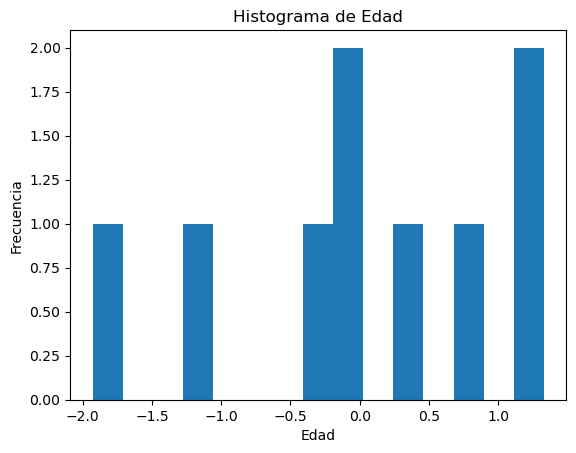

In [45]:
import matplotlib.pyplot as plt

plt.hist(df_procesado['Edad'], bins=15,)
plt.title('Histograma de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

In [55]:
X_scalado=df_procesado.drop(['id_clientes','Acepta_Tarjeta','index'],axis=1)
X_scalado

,Edad,Salario_Estimado,Saldo_Bancario,Genero,Nivel_Educativo,Estado_Civil_Divorciado,Estado_Civil_Soltero
0,1.328826,-0.433013,0.225484,1.0,0.0,False,True
1,-0.361775,0.216506,1.071584,1.0,1.5,False,True
2,-0.111315,-1.082532,-1.276156,1.0,1.5,True,False
3,0.013914,-0.433013,-1.295762,0.0,-1.5,False,True
4,1.140982,-1.082532,0.305358,0.0,-1.5,False,True
5,-1.927146,1.299038,1.212714,1.0,0.0,False,False
6,0.326989,1.299038,1.276370,1.0,0.0,False,True
7,0.765293,1.299038,-1.029679,0.0,0.0,True,False
8,-1.175768,-1.082532,-0.489912,0.0,0.0,True,False


In [56]:
y=df_procesado['Acepta_Tarjeta']
y

0    0
1    0
2    0
3    1
4    1
5    1
6    1
7    1
8    1
Name: Acepta_Tarjeta, dtype: int32

In [ ]:
#validacion cruzada
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scalado,y,test_side=0.2,random_state=42)